In [11]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Load predictions
with open("../data/predictions.pkl", "rb") as f:
    predictions = pickle.load(f)

ASSETS = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'SPY', 'GLD']

print("Predictions loaded!")

Predictions loaded!


In [12]:
# Combine all predictions into one dataframe
pred_returns = pd.DataFrame()
actual_returns = pd.DataFrame()

for asset in ASSETS:
    pred_returns[asset] = predictions[asset]['y_pred']
    actual_returns[asset] = predictions[asset]['y_test'].values

print("Predicted returns shape:", pred_returns.shape)
print("Actual returns shape:", actual_returns.shape)
pred_returns.head()

Predicted returns shape: (292, 6)
Actual returns shape: (292, 6)


,AAPL,MSFT,NVDA,JPM,SPY,GLD
0,-0.003420,-0.004760,-0.001190,-0.000103,-0.001780,0.000230
1,0.004345,0.000330,-0.003678,0.000555,0.000645,0.000322
2,0.001379,0.005305,-0.000425,0.000936,0.000501,-0.000633
3,0.001251,0.009810,0.003303,0.002329,0.001663,0.000252
4,0.001819,0.002493,0.002614,0.001298,0.002413,-0.000311


In [13]:
def get_ml_weights(pred_returns, all_features, max_weight=0.20):
    weights = pd.DataFrame(index=pred_returns.index, columns=pred_returns.columns)
    
    for i in range(len(pred_returns)):
        row = pred_returns.iloc[i]
        
        # Get predicted volatility for each asset
        vol = pd.Series(index=ASSETS, dtype=float)
        for asset in ASSETS:
            feat = all_features[asset]
            if i < len(feat):
                vol[asset] = feat['volatility_10'].iloc[i]
            else:
                vol[asset] = 1.0
        
        # Replace zeros to avoid division by zero
        vol = vol.replace(0, vol.mean())
        vol = vol.fillna(vol.mean())
        
        # Risk adjusted signal = predicted return / volatility
        signal = row / vol
        
        # Only positive signals
        positive = signal[signal > 0]
        
        if len(positive) == 0:
            w = pd.Series(1/len(ASSETS), index=ASSETS)
        else:
            w = positive / positive.sum()
            w = w.clip(upper=max_weight)
            w = w / w.sum()
            full_w = pd.Series(0.0, index=ASSETS)
            full_w[w.index] = w
            w = full_w
        
        weights.iloc[i] = w
    
    return weights.astype(float)

In [14]:
# Load all_features
with open("../data/all_features.pkl", "rb") as f:
    all_features = pickle.load(f)

ml_weights = get_ml_weights(pred_returns, all_features)
print("Weights shape:", ml_weights.shape)
print("\nSample weights (first day):")
print(ml_weights.iloc[0].round(3))

Weights shape: (292, 6)

Sample weights (first day):
AAPL    0.0
MSFT    0.0
NVDA    0.0
JPM     0.0
SPY     0.0
GLD     1.0
Name: 0, dtype: float64


In [15]:
# ML Portfolio daily returns
ml_portfolio_returns = (ml_weights.values * actual_returns.values).sum(axis=1)

# Equal weight portfolio (baseline)
equal_weights = np.ones((len(actual_returns), len(ASSETS))) / len(ASSETS)
equal_portfolio_returns = (equal_weights * actual_returns.values).sum(axis=1)

# Convert to pandas Series
ml_portfolio_returns = pd.Series(ml_portfolio_returns)
equal_portfolio_returns = pd.Series(equal_portfolio_returns)

print("ML Portfolio avg daily return:", ml_portfolio_returns.mean().round(6))
print("Equal Weight avg daily return:", equal_portfolio_returns.mean().round(6))

ML Portfolio avg daily return: 0.003478
Equal Weight avg daily return: 0.001608


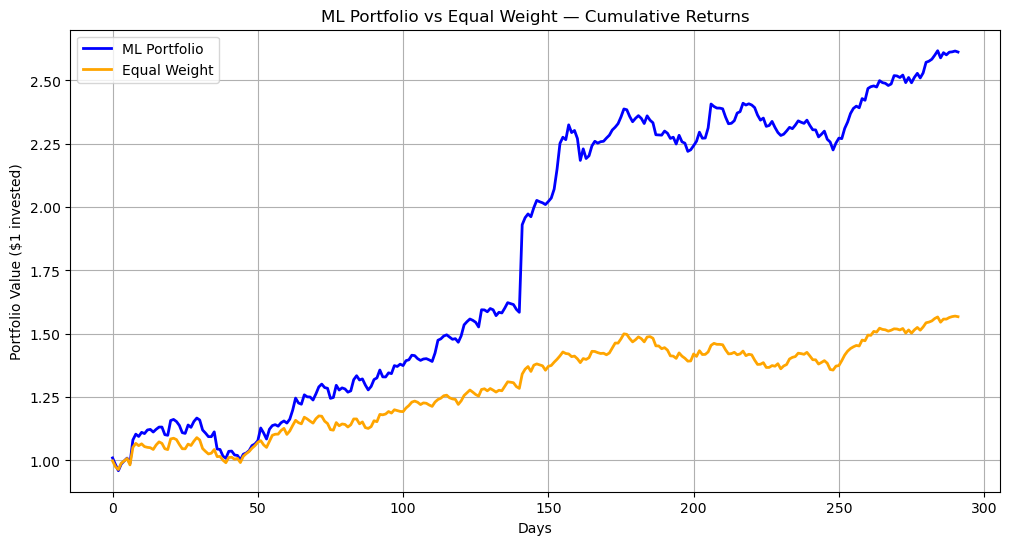

ML Final Value: $2.61
Equal Weight Final Value: $1.57


In [16]:
# Cumulative returns
ml_cumulative = (1 + ml_portfolio_returns).cumprod()
equal_cumulative = (1 + equal_portfolio_returns).cumprod()

plt.figure(figsize=(12, 6))
ml_cumulative.plot(label='ML Portfolio', color='blue', linewidth=2)
equal_cumulative.plot(label='Equal Weight', color='orange', linewidth=2)
plt.title('ML Portfolio vs Equal Weight — Cumulative Returns')
plt.xlabel('Days')
plt.ylabel('Portfolio Value ($1 invested)')
plt.legend()
plt.grid(True)
plt.show()

print(f"ML Final Value: ${ml_cumulative.iloc[-1]:.2f}")
print(f"Equal Weight Final Value: ${equal_cumulative.iloc[-1]:.2f}")

In [17]:
# Weekly rebalancing (every 5 days instead of daily)
TRANSACTION_COST = 0.001

# Only rebalance every 5 days
ml_weights_weekly = ml_weights.copy()
for i in range(len(ml_weights)):
    if i % 5 != 0:  # not a rebalancing day
        ml_weights_weekly.iloc[i] = ml_weights_weekly.iloc[i-1]

# Calculate costs with weekly rebalancing
weight_changes = ml_weights_weekly.diff().abs().sum(axis=1)
daily_costs = weight_changes * TRANSACTION_COST
ml_portfolio_returns_after_costs = ml_portfolio_returns - daily_costs

print(f"Average daily cost: {daily_costs.mean():.6f}")
print(f"Annual cost drag: {daily_costs.mean() * 252 * 100:.2f}%")

Average daily cost: 0.000231
Annual cost drag: 5.81%


In [18]:
# Risk free rate (approximate)
rf = 0.05 / 252  # 5% annual, converted to daily

def portfolio_metrics(returns, rf=rf):
    sharpe = (returns.mean() - rf) / returns.std() * np.sqrt(252)
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    return {
        'Sharpe Ratio': round(sharpe, 2),
        'Max Drawdown': f"{round(max_drawdown * 100, 2)}%",
        'Annual Return': f"{round(returns.mean() * 252 * 100, 2)}%",
        'Daily Volatility': f"{round(returns.std() * 100, 2)}%"
    }

ml_metrics = portfolio_metrics(ml_portfolio_returns_after_costs)
equal_metrics = portfolio_metrics(equal_portfolio_returns)

print("ML Portfolio:")
for k, v in ml_metrics.items():
    print(f"  {k}: {v}")

print("\nEqual Weight:")
for k, v in equal_metrics.items():
    print(f"  {k}: {v}")

ML Portfolio:
  Sharpe Ratio: 2.45
  Max Drawdown: -14.44%
  Annual Return: 81.83%
  Daily Volatility: 1.98%

Equal Weight:
  Sharpe Ratio: 1.92
  Max Drawdown: -9.53%
  Annual Return: 40.52%
  Daily Volatility: 1.17%


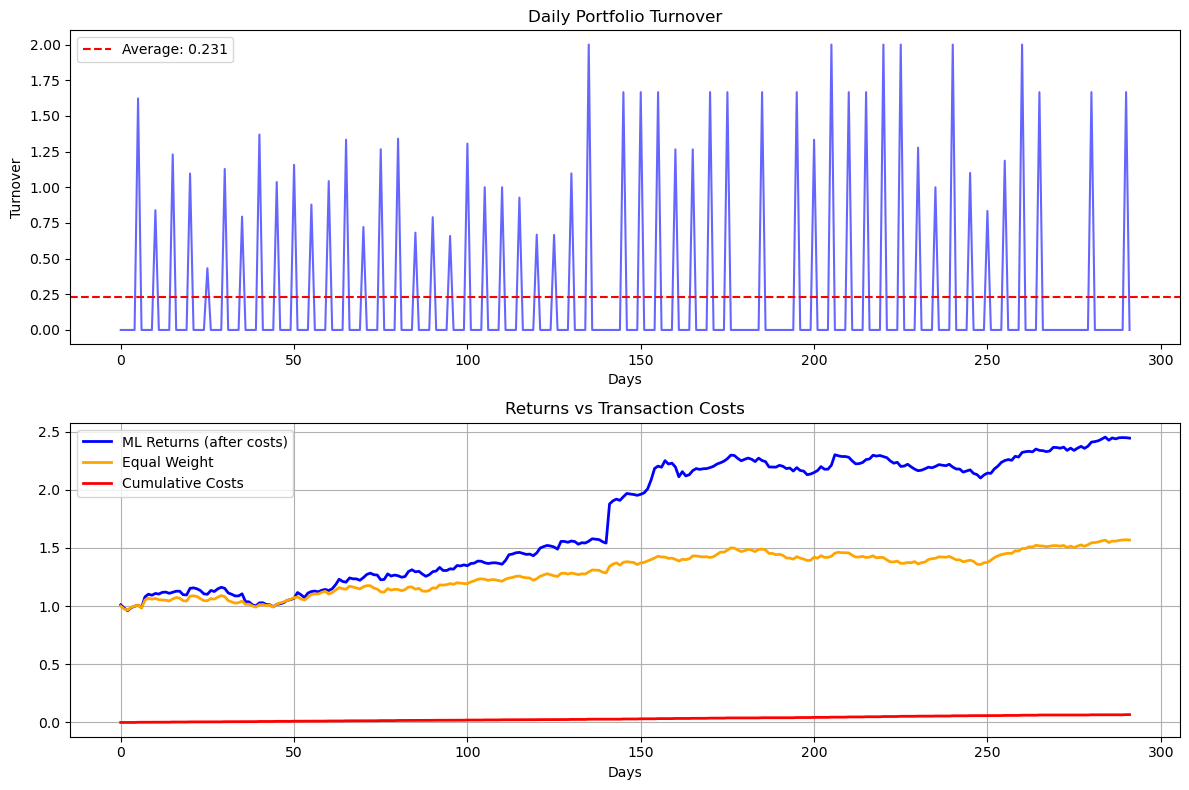

Average daily turnover: 0.231
Annual turnover: 58.1x
Total transaction costs: 0.0673


In [19]:
# Turnover Analysis
turnover = ml_weights_weekly.diff().abs().sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Daily turnover
turnover.plot(ax=axes[0], color='blue', alpha=0.6)
axes[0].axhline(turnover.mean(), color='red', linestyle='--', 
                label=f'Average: {turnover.mean():.3f}')
axes[0].set_title('Daily Portfolio Turnover')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Turnover')
axes[0].legend()

# Cumulative cost vs cumulative return
ml_cumulative_after = (1 + ml_portfolio_returns_after_costs).cumprod()
cost_cumulative = daily_costs.cumsum()

ml_cumulative_after.plot(ax=axes[1], label='ML Returns (after costs)', 
                         color='blue', linewidth=2)
equal_cumulative.plot(ax=axes[1], label='Equal Weight', 
                      color='orange', linewidth=2)
cost_cumulative.plot(ax=axes[1], label='Cumulative Costs', 
                     color='red', linewidth=2)
axes[1].set_title('Returns vs Transaction Costs')
axes[1].set_xlabel('Days')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Average daily turnover: {turnover.mean():.3f}")
print(f"Annual turnover: {turnover.mean() * 252:.1f}x")
print(f"Total transaction costs: {daily_costs.sum():.4f}")

BULL MARKET Performance:
  ML Sharpe:    4.09
  Equal Sharpe: 3.64

BEAR MARKET Performance:
  ML Sharpe:    -1.56
  Equal Sharpe: -0.80


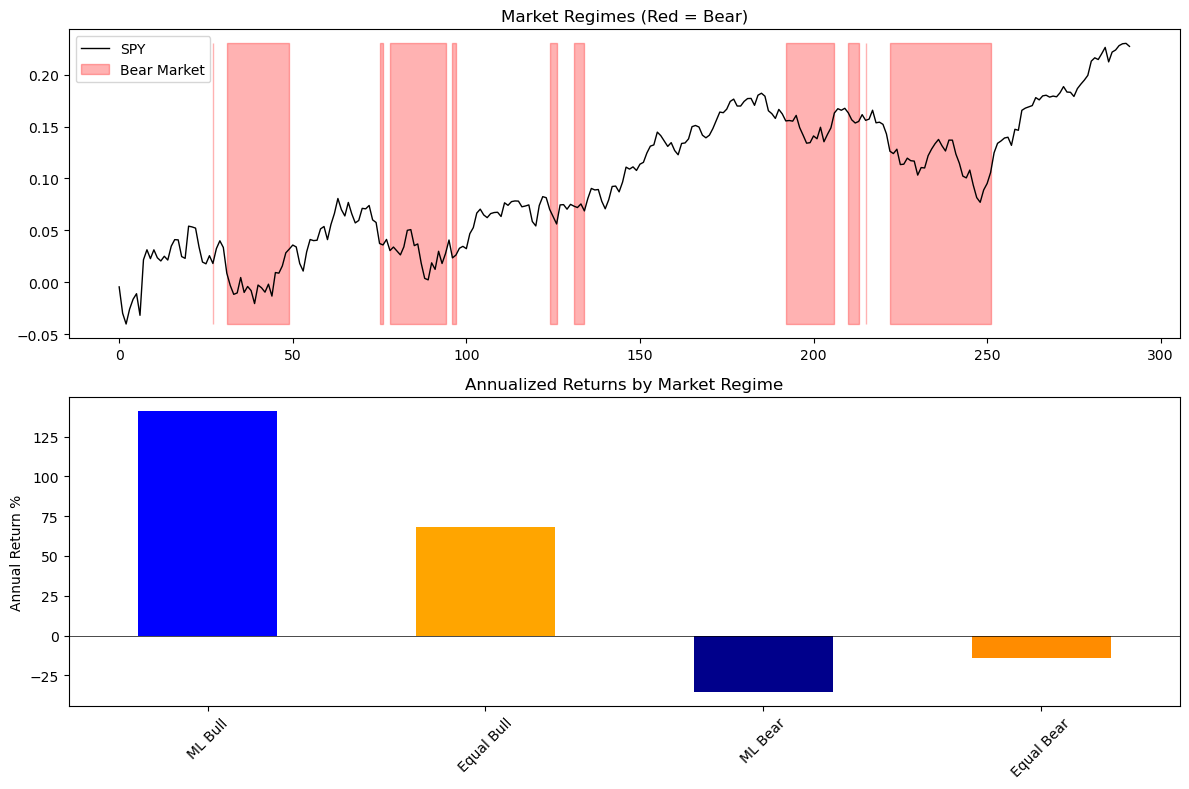

In [20]:
# Regime Analysis
# Define market regimes based on SPY rolling returns
spy_returns = actual_returns['SPY']
spy_rolling = spy_returns.rolling(20).mean()

# Bull = SPY trending up, Bear = SPY trending down
regime = pd.Series('Bull', index=spy_returns.index)
regime[spy_rolling < 0] = 'Bear'

# Portfolio performance by regime
ml_returns = ml_portfolio_returns_after_costs.values
equal_returns = equal_portfolio_returns.values

bull_days = regime == 'Bull'
bear_days = regime == 'Bear'

print("BULL MARKET Performance:")
print(f"  ML Sharpe:    {(pd.Series(ml_returns[bull_days]).mean() / pd.Series(ml_returns[bull_days]).std() * np.sqrt(252)):.2f}")
print(f"  Equal Sharpe: {(pd.Series(equal_returns[bull_days]).mean() / pd.Series(equal_returns[bull_days]).std() * np.sqrt(252)):.2f}")

print("\nBEAR MARKET Performance:")
print(f"  ML Sharpe:    {(pd.Series(ml_returns[bear_days]).mean() / pd.Series(ml_returns[bear_days]).std() * np.sqrt(252)):.2f}")
print(f"  Equal Sharpe: {(pd.Series(equal_returns[bear_days]).mean() / pd.Series(equal_returns[bear_days]).std() * np.sqrt(252)):.2f}")

# Plot regime
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Regime overlay
spy_returns.cumsum().plot(ax=axes[0], color='black', linewidth=1)
axes[0].fill_between(range(len(regime)), 
                      spy_returns.cumsum().min(), 
                      spy_returns.cumsum().max(),
                      where=bear_days.values,
                      alpha=0.3, color='red', label='Bear Market')
axes[0].set_title('Market Regimes (Red = Bear)')
axes[0].legend()

# Performance by regime
ml_bull = pd.Series(ml_returns) * bull_days.values
ml_bear = pd.Series(ml_returns) * bear_days.values
equal_bull = pd.Series(equal_returns) * bull_days.values
equal_bear = pd.Series(equal_returns) * bear_days.values

data = {
    'ML Bull': ml_bull[bull_days.values].mean() * 252 * 100,
    'Equal Bull': equal_bull[bull_days.values].mean() * 252 * 100,
    'ML Bear': ml_bear[bear_days.values].mean() * 252 * 100,
    'Equal Bear': equal_bear[bear_days.values].mean() * 252 * 100
}

pd.Series(data).plot(kind='bar', ax=axes[1], 
                     color=['blue', 'orange', 'darkblue', 'darkorange'])
axes[1].set_title('Annualized Returns by Market Regime')
axes[1].set_ylabel('Annual Return %')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [21]:
!pip install streamlit